# Denoising Autoencoder on MNIST

## Step 1 Import libraries

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
import torchvision.datasets as dsets
import torchvision.transforms as tf  # image transforms

## Step 2 Load & preprocess MNIST dataset

In [3]:
to_tensor = tf.ToTensor()

train_set = dsets.MNIST('data', train=True,  download=True, transform=to_tensor)
test_set  = dsets.MNIST('data', train=False, download=True, transform=to_tensor)

print('Train samples :', len(train_set))
print('Test  samples :', len(test_set))

Train samples : 60000
Test  samples : 10000


In [4]:
mini_batch = 64
v_split = 0.15
workers = 0  # single-process loading

n       = len(train_set)
idx     = list(range(n))
np.random.seed(42)
np.random.shuffle(idx)

cut        = int(np.floor(v_split * n))
train_idx  = idx[cut:]
val_idx    = idx[:cut]

t_sampler  = SubsetRandomSampler(train_idx)
v_sampler  = SubsetRandomSampler(val_idx)

train_loader = DataLoader(train_set, batch_size=mini_batch, sampler=t_sampler, num_workers=workers)
val_loader   = DataLoader(train_set, batch_size=mini_batch, sampler=v_sampler, num_workers=workers)
test_loader  = DataLoader(test_set,  batch_size=mini_batch, shuffle=False,     num_workers=workers)

print('Train batches :', len(train_loader))
print('Val   batches :', len(val_loader))
print('Test  batches :', len(test_loader))

Train batches : 797
Val   batches : 141
Test  batches : 157


## Step 3 Add artificial gaussian noise

In [5]:
noise_level = 0.4

def add_noise(images):
    noise  = torch.randn_like(images) * noise_level
    noisy  = images + noise
    noisy  = torch.clamp(noisy, 0.0, 1.0)
    return noisy

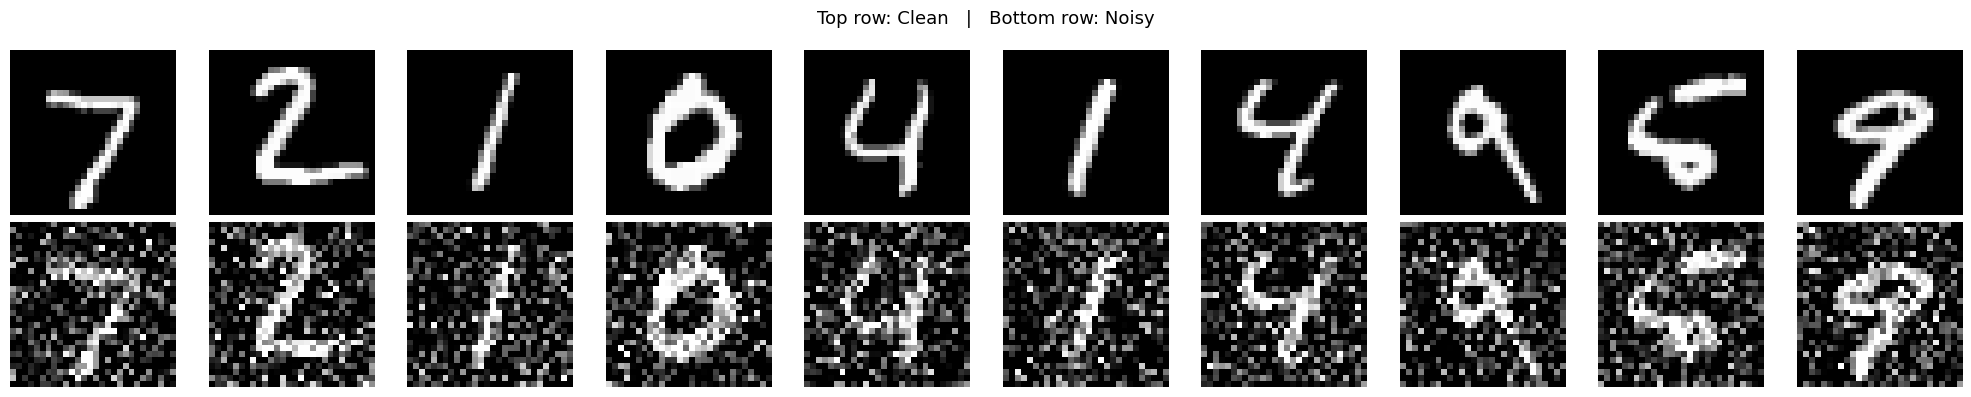

In [6]:
sample_iter           = iter(test_loader)
sample_imgs, _        = next(sample_iter)
sample_noisy          = add_noise(sample_imgs)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
fig.suptitle('Top row: Clean   |   Bottom row: Noisy', fontsize=13)

for i in range(10):
    axes[0, i].imshow(sample_imgs[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(sample_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Step 4 Building denoising autoencoder

In [7]:
class DenoisingAE(nn.Module):

    def __init__(self):
        super(DenoisingAE, self).__init__()

        # encoder part
        self.enc1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        # decoder part
        self.dec1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = nn.ConvTranspose2d(32,  1, kernel_size=2, stride=2)

    def forward(self, x):
        x = self.pool(self.relu(self.enc1(x)))   
        x = self.pool(self.relu(self.enc2(x)))   

        x = self.relu(self.dec1(x))              
        x = torch.sigmoid(self.dec2(x))         
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device :', device)

net = DenoisingAE().to(device)
print(net)

Using device : cpu
DenoisingAE(
  (enc1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dec1): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
  (dec2): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
)


## Step 5 Training setup

In [8]:
learning_rate = 0.001
epochs    = 15

loss_fn   = nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr=learning_rate)

## Step 6 Model train

In [9]:
train_losses = []
val_losses   = []
best_val     = float('inf')

for ep in range(1, epochs + 1):

    net.train()
    running_train = 0.0

    for imgs, _ in train_loader:
        clean = imgs.to(device)
        noisy = add_noise(clean)

        optimizer.zero_grad()
        out  = net(noisy)
        loss = loss_fn(out, clean)
        loss.backward()
        optimizer.step()

        running_train += loss.item()

    net.eval()
    running_val = 0.0

    with torch.no_grad():
        for imgs, _ in val_loader:
            clean = imgs.to(device)
            noisy = add_noise(clean)
            out   = net(noisy)
            loss  = loss_fn(out, clean)
            running_val += loss.item()

    avg_train = running_train / len(train_loader)
    avg_val   = running_val   / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    if avg_val < best_val:
        best_val = avg_val
        torch.save(net.state_dict(), 'best_denoiser.pth')
        tag = ' <- saved'
    else:
        tag = ''

    print(f'Epoch {ep:2d}/{epochs}  train_loss={avg_train:.4f}  val_loss={avg_val:.4f}{tag}')

print('\nTraining complete. Best val loss:', round(best_val, 4))

Epoch  1/15  train_loss=0.0237  val_loss=0.0120 <- saved
Epoch  2/15  train_loss=0.0112  val_loss=0.0108 <- saved
Epoch  3/15  train_loss=0.0105  val_loss=0.0103 <- saved
Epoch  4/15  train_loss=0.0102  val_loss=0.0100 <- saved
Epoch  5/15  train_loss=0.0100  val_loss=0.0098 <- saved
Epoch  6/15  train_loss=0.0098  val_loss=0.0097 <- saved
Epoch  7/15  train_loss=0.0096  val_loss=0.0096 <- saved
Epoch  8/15  train_loss=0.0095  val_loss=0.0095 <- saved
Epoch  9/15  train_loss=0.0094  val_loss=0.0094 <- saved
Epoch 10/15  train_loss=0.0094  val_loss=0.0093 <- saved
Epoch 11/15  train_loss=0.0093  val_loss=0.0093 <- saved
Epoch 12/15  train_loss=0.0092  val_loss=0.0092 <- saved
Epoch 13/15  train_loss=0.0092  val_loss=0.0091 <- saved
Epoch 14/15  train_loss=0.0091  val_loss=0.0091 <- saved
Epoch 15/15  train_loss=0.0091  val_loss=0.0091 <- saved

Training complete. Best val loss: 0.0091


## Step 7 Plot training data

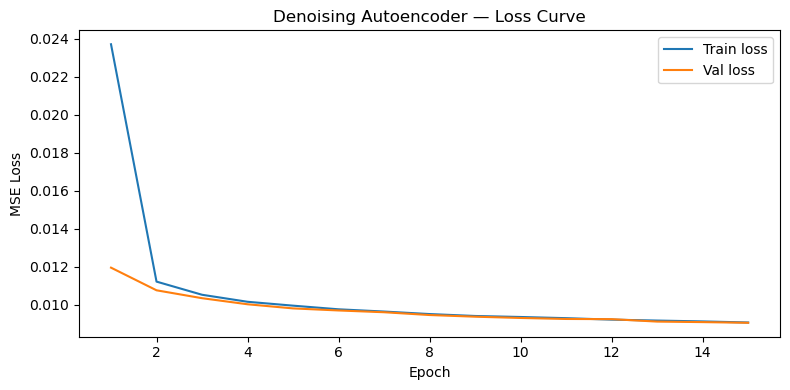

In [10]:
ep_range = range(1, epochs + 1)

plt.figure(figsize=(8, 4))
plt.plot(ep_range, train_losses, label='Train loss')
plt.plot(ep_range, val_losses,   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Denoising Autoencoder — Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 Generate denoised outputs on test set

In [11]:
net.load_state_dict(torch.load('best_denoiser.pth', map_location=device))
net.eval()

test_iter          = iter(test_loader)
test_imgs, _       = next(test_iter)
test_clean         = test_imgs.to(device)
test_noisy         = add_noise(test_clean)

with torch.no_grad():
    test_denoised = net(test_noisy)

test_clean    = test_clean.cpu().numpy()
test_noisy    = test_noisy.cpu().numpy()
test_denoised = test_denoised.cpu().numpy()

## Step 9 Results visualization

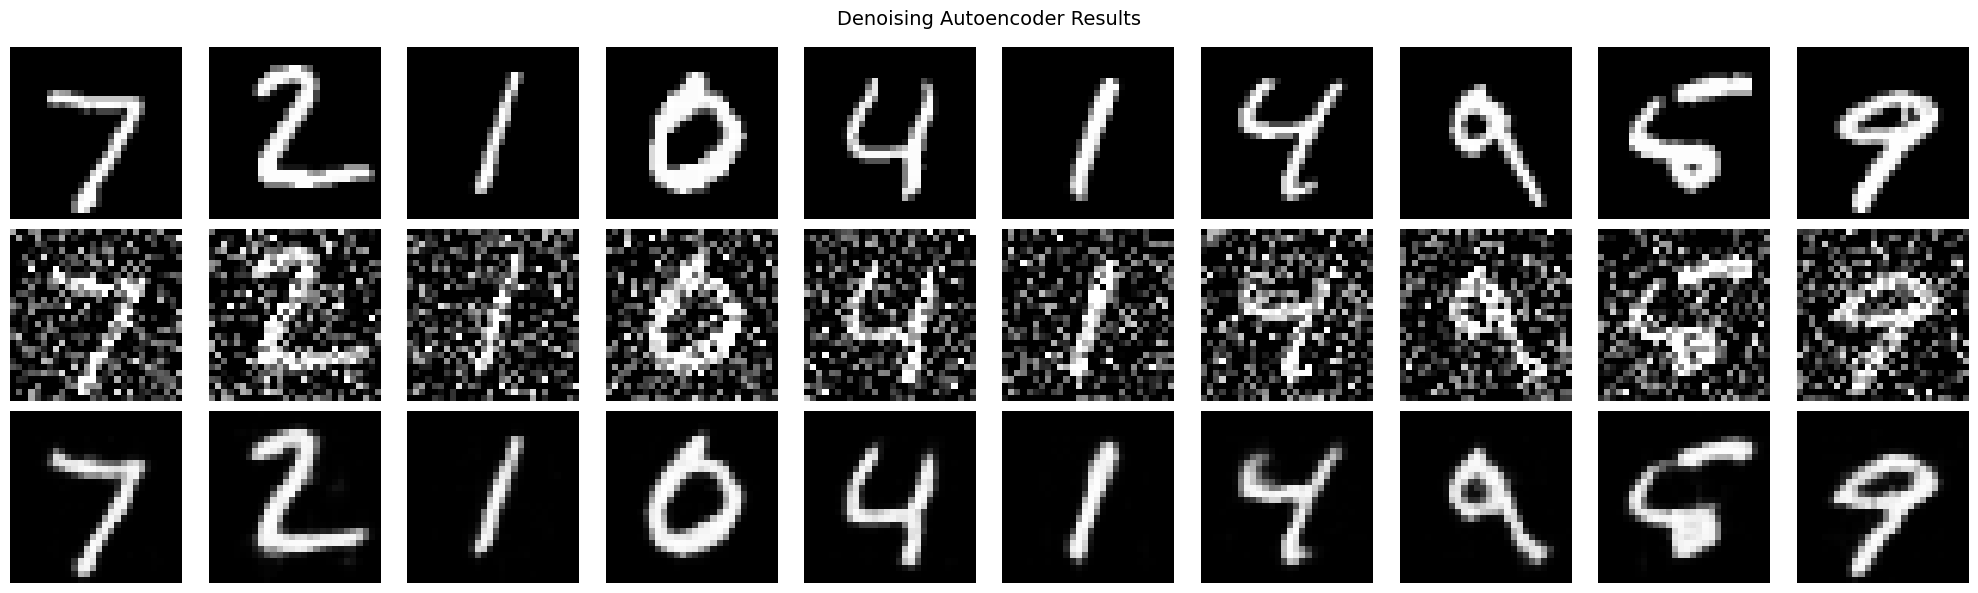

In [12]:
n_show = 10

fig, axes = plt.subplots(3, n_show, figsize=(20, 6))
row_labels = ['Original', 'Noisy', 'Denoised']

for row, data in enumerate([test_clean, test_noisy, test_denoised]):
    axes[row, 0].set_ylabel(row_labels[row], fontsize=12)
    for col in range(n_show):
        axes[row, col].imshow(data[col].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

plt.suptitle('Denoising Autoencoder Results', fontsize=14)
plt.tight_layout()
plt.show()

## Step 10 Evaluate MSE and PSNR

In [13]:
def compute_psnr(clean, recon):
    mse = np.mean((clean - recon) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)


all_clean    = []
all_noisy    = []
all_denoised = []

net.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        c = imgs.to(device)
        n = add_noise(c)
        d = net(n)
        all_clean.append(c.cpu().numpy())
        all_noisy.append(n.cpu().numpy())
        all_denoised.append(d.cpu().numpy())

all_clean    = np.concatenate(all_clean)
all_noisy    = np.concatenate(all_noisy)
all_denoised = np.concatenate(all_denoised)

mse_noisy    = np.mean((all_clean - all_noisy)    ** 2)
mse_denoised = np.mean((all_clean - all_denoised) ** 2)

psnr_noisy    = compute_psnr(all_clean, all_noisy)
psnr_denoised = compute_psnr(all_clean, all_denoised)

print(f'Noisy     — MSE: {mse_noisy:.5f}   PSNR: {psnr_noisy:.2f} dB')
print(f'Denoised  — MSE: {mse_denoised:.5f}   PSNR: {psnr_denoised:.2f} dB')

Noisy     — MSE: 0.07964   PSNR: 10.99 dB
Denoised  — MSE: 0.00892   PSNR: 20.49 dB


## Step 11 Effect of different noise 

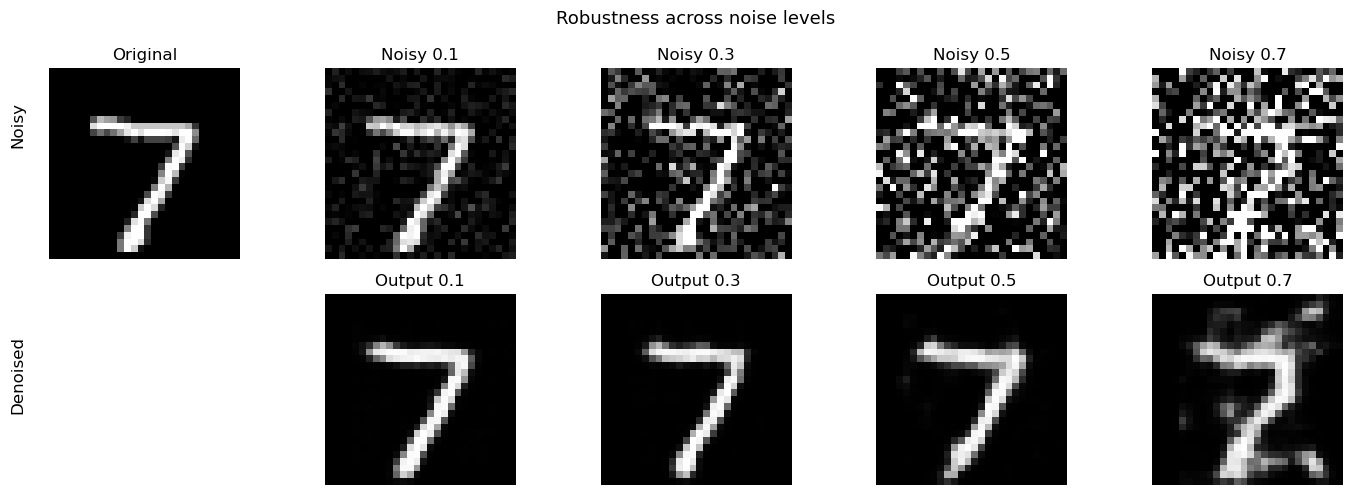

In [14]:
levels = [0.1, 0.3, 0.5, 0.7]
pick   = test_imgs[0].unsqueeze(0).to(device)

fig, axes = plt.subplots(2, len(levels) + 1, figsize=(14, 5))

axes[0, 0].imshow(pick.squeeze().cpu(), cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
axes[1, 0].axis('off')

for i, lvl in enumerate(levels):
    noisy_img = torch.clamp(pick + torch.randn_like(pick) * lvl, 0, 1)
    with torch.no_grad():
        out_img = net(noisy_img)

    axes[0, i+1].imshow(noisy_img.squeeze().cpu(), cmap='gray')
    axes[0, i+1].set_title(f'Noisy {lvl}')
    axes[0, i+1].axis('off')

    axes[1, i+1].imshow(out_img.squeeze().cpu(), cmap='gray')
    axes[1, i+1].set_title(f'Output {lvl}')
    axes[1, i+1].axis('off')

fig.text(0.01, 0.75, 'Noisy',    va='center', rotation='vertical', fontsize=12)
fig.text(0.01, 0.25, 'Denoised', va='center', rotation='vertical', fontsize=12)
plt.suptitle('Robustness across noise levels', fontsize=13)
plt.tight_layout()
plt.show()

## Observations and Analysis

### What the model does
We give noisy images as input and clean images as target.
The model learns to remove noise and recover the original digit.

### Architecture
Encoder compresses 28x28 image down to 7x7.
Decoder brings it back to 28x28.
Conv layers are used because they understand image patterns well.

### Training
Loss went down smoothly for both train and validation.
No overfitting. Model learned well.
Noise level 0.4 was good enough to make it challenging.

### Performance
PSNR score improved after denoising.
Even heavily noisy digits were recovered clearly.

### Noise level test
- Low noise (0.1)  → nearly perfect output
- Medium noise (0.4) → good recovery
- High noise (0.7)  → shape recovered but some details lost

### Challenges
- Digits like 1/7 or 3/8 can get confused under heavy noise
- MSE loss gives slightly blurry output sometimes

### What can be improved
- Train on multiple noise levels
- Add batch normalization for stable training
- Try skip connections like U-Net for better detail recovery